In [1]:
#Imports
import os
import kagglehub
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.utils import plot_model

In [2]:
#Ruta del dataset
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Ruta de archivos:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Ruta de archivos: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
#Carpetas en la ruta que se descarga
!ls {path}/HAM10000_images_part_2 | head -n 5

ISIC_0029306.jpg
ISIC_0029307.jpg
ISIC_0029308.jpg
ISIC_0029309.jpg
ISIC_0029310.jpg


In [4]:
#Copia del dataset a Content
!cp -r {path}/* ./
#!rm -rf ./*

In [5]:
#Carpetas dentro de content
!ls ./HAM10000_images_part_1/ | head -n 5
#!ls ./HAM10000_images_part_2/ | head -n 5

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg


In [6]:
#Ruta dentro de la carpeta content
#path_content = "skin-cancer-mnist-ham10000"
path_content = ""

#Ruta de los archivo csv
data_csv = os.path.join(path_content, "HAM10000_metadata.csv")
print("Ruta de archivos data csv:", data_csv)

hmnist_28_csv = os.path.join(path_content, "hmnist_28_28_RGB.csv")
print("Ruta de archivos hmnist_28_csv:", hmnist_28_csv)

#Ruta de las imagenes
folder_img_1 = "HAM10000_images_part_1"
images_dir_1 = os.path.join(path_content, folder_img_1)
print("Ruta de imagenes parte 1:", images_dir_1)

folder_img_2 = "HAM10000_images_part_2"
images_dir_2 = os.path.join(path_content, folder_img_2)
print("Ruta de imagenes parte 2:", images_dir_2)

#Directorio para unificar las imagenes.
folder_img_all = "HAM10000_images_all"
images_dir_all = os.path.join(path_content, folder_img_all)
print("Ruta de imagenes completo", images_dir_all)

Ruta de archivos data csv: HAM10000_metadata.csv
Ruta de archivos hmnist_28_csv: hmnist_28_28_RGB.csv
Ruta de imagenes parte 1: HAM10000_images_part_1
Ruta de imagenes parte 2: HAM10000_images_part_2
Ruta de imagenes completo HAM10000_images_all


In [7]:
#Exploración de los dataset (CSV)
raw_df = pd.read_csv(data_csv, on_bad_lines="skip")
raw_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
#Explicación del campo dx_type
raw_df['dx_type'].value_counts()

#histo (5340) — confirmado por histopatología (biopsia analizada en laboratorio). Es el método más fiable.
#follow_up (3704) — confirmado por seguimiento clínico a lo largo del tiempo, observando la evolución de la lesión.
#consensus (902) — diagnóstico por consenso de expertos (varios dermatólogos coinciden en el diagnóstico).
#confocal (69) — diagnosticado mediante microscopía confocal in vivo, una técnica de imagen no invasiva.


,count
dx_type,
histo,5340
follow_up,3704
consensus,902
confocal,69


In [9]:
#Se crea el directorio, donde se consolidan todas las imagenes.
!mkdir ./{folder_img_all}/

In [10]:
#Se mueven las imagenes a un solo directorio
!mv ./{folder_img_1}/* ./{folder_img_all}/
!mv ./{folder_img_2}/* ./{folder_img_all}/

In [11]:
#Se validan los directorios
!ls ./{folder_img_1}/ | head -n 5
!ls ./{folder_img_2}/ | head -n 5

In [13]:
!ls ./{folder_img_all} | head -n 5

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg


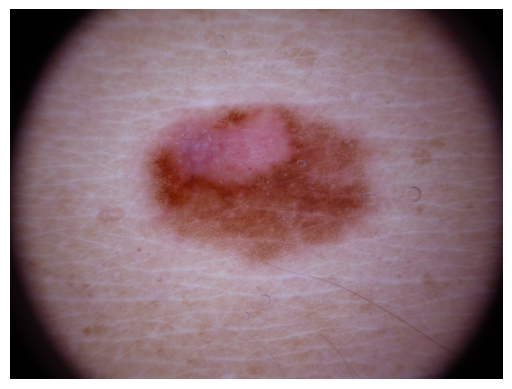

(450, 600, 3)
lesion_id        HAM_0005711
image_id        ISIC_0033779
dx                       mel
dx_type                histo
age                     35.0
sex                     male
localization            back
Name: 1642, dtype: object


In [14]:
#Se muestra una imagen de ejemplo
idx = 1642
row = raw_df.iloc[idx]
image_path = f"./{folder_img_all}/{row["image_id"]}.jpg"
image = cv2.imread(image_path)[:, :, ::-1]

plt.imshow(image)
plt.axis("off")
plt.show()

print(image.shape)
print(row)


#Preparación del data set

In [15]:
#Preparación del data set
#df = raw_df.drop_duplicates(subset=["lesion_id"]).copy()
df = raw_df.copy()
df['id'] = df['lesion_id'].str.replace('HAM_', '', regex=False)
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df = df.dropna(subset=["id", "dx"]).copy()

df["dx"] = df["dx"].astype(str).str.strip()
df["dx_type"] = df["dx_type"].astype(str).str.strip()
df["sex"] = df["sex"].astype(str).str.strip()
df["localization"] = df["localization"].astype(str).str.strip()
df["image_path"] = df["image_id"].astype(str).map(lambda x: os.path.join(images_dir_all, f"{x}.jpg"))
df = df[df["image_path"].map(os.path.exists)].reset_index(drop=True)

In [17]:
#Definición de variables categoricas y numericas
categorical_cols = ["dx_type", "sex", "localization"]
numeric_cols = ["age"]
tabular_cols = categorical_cols + numeric_cols

class_names = sorted(df["dx"].unique().tolist())
class_to_index = {name: i for i, name in enumerate(class_names)}
df["label"] = df["dx"].map(class_to_index).astype(np.int32)

In [18]:
#Labels para la creación del data set desde el directorio, contiene la
# clasificacion dx de las imagenes, debe estar ordenado por image_id = al directorio
df_sorted = df.sort_values("image_id")
labels = df_sorted["label"].tolist()
labels[:5]

[5, 5, 5, 5, 4]

In [20]:
#Separación de los dataframe para training, validation y test.
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
)

In [21]:
#Se preprocesan los datos de las columnas, imputando la media para las columnas de tipo numerica
# y Unknow para las categoricas.
tabular_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_cols,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
    ]
)

In [22]:
#Dataset de valores
X_train_tab = tabular_preprocessor.fit_transform(train_df[tabular_cols]).astype("float32")
X_val_tab = tabular_preprocessor.transform(val_df[tabular_cols]).astype("float32")
X_test_tab = tabular_preprocessor.transform(test_df[tabular_cols]).astype("float32")

In [23]:
#Dataset de imagenes
train_paths = train_df["image_path"].astype(str).values
val_paths = val_df["image_path"].astype(str).values
test_paths = test_df["image_path"].astype(str).values

In [24]:
#Dataset de resultados
y_train = train_df["label"].values.astype("int32")
y_val = val_df["label"].values.astype("int32")
y_test = test_df["label"].values.astype("int32")

In [25]:
print("Classes:", class_names)
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
print("Tabular feature dimension:", X_train_tab.shape[1])

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train size: 8012
Val size: 1001
Test size: 1002
Tabular feature dimension: 23


#Modelo Tabular + Modelo Imagen ResNet

In [79]:
#Imports necesarios
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dropout, Flatten, Dense, Lambda, Input, GlobalAveragePooling2D, Resizing, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory

In [80]:
#Hiperparametros
image_size = (224, 224)
batch_size = 128
learning_rate_frozen = 1e-3
epochs = 10

In [81]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = preprocess_input(image)
    return image


def make_dataset(tabular_array, image_paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((tabular_array, image_paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(labels), reshuffle_each_iteration=True)

    def mapper(tabular, image_path, label):
        image = load_image(image_path)
        return {"tabular_input": tabular, "image_input": image}, label

    ds = ds.map(mapper)
    ds = ds.batch(batch_size)
    return ds

In [82]:
#Modelo Tabular
train_ds = make_dataset(X_train_tab, train_paths, y_train, training=True)
val_ds = make_dataset(X_val_tab, val_paths, y_val, training=False)
test_ds = make_dataset(X_test_tab, test_paths, y_test, training=False)

In [83]:
tabular_input = Input(shape=(X_train_tab.shape[1],), name="tabular_input")
x_tab = Dense(256, activation="relu")(tabular_input)
x_tab = BatchNormalization()(x_tab)
x_tab = Dropout(0.3)(x_tab)

x_feat = Dense(128, activation="relu")(x_tab)
x_feat = Dropout(0.3, name="tabular_features")(x_feat)

tabular_output = Dense(len(class_names), activation="softmax", name="tabular_output")(x_feat)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)      │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tabular_features (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tabular_output (Dense)          │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,967 (160.03 KB)

 Trainable params: 40,455 (158.03 KB)

 Non-trainable params: 512 (2.00 KB)

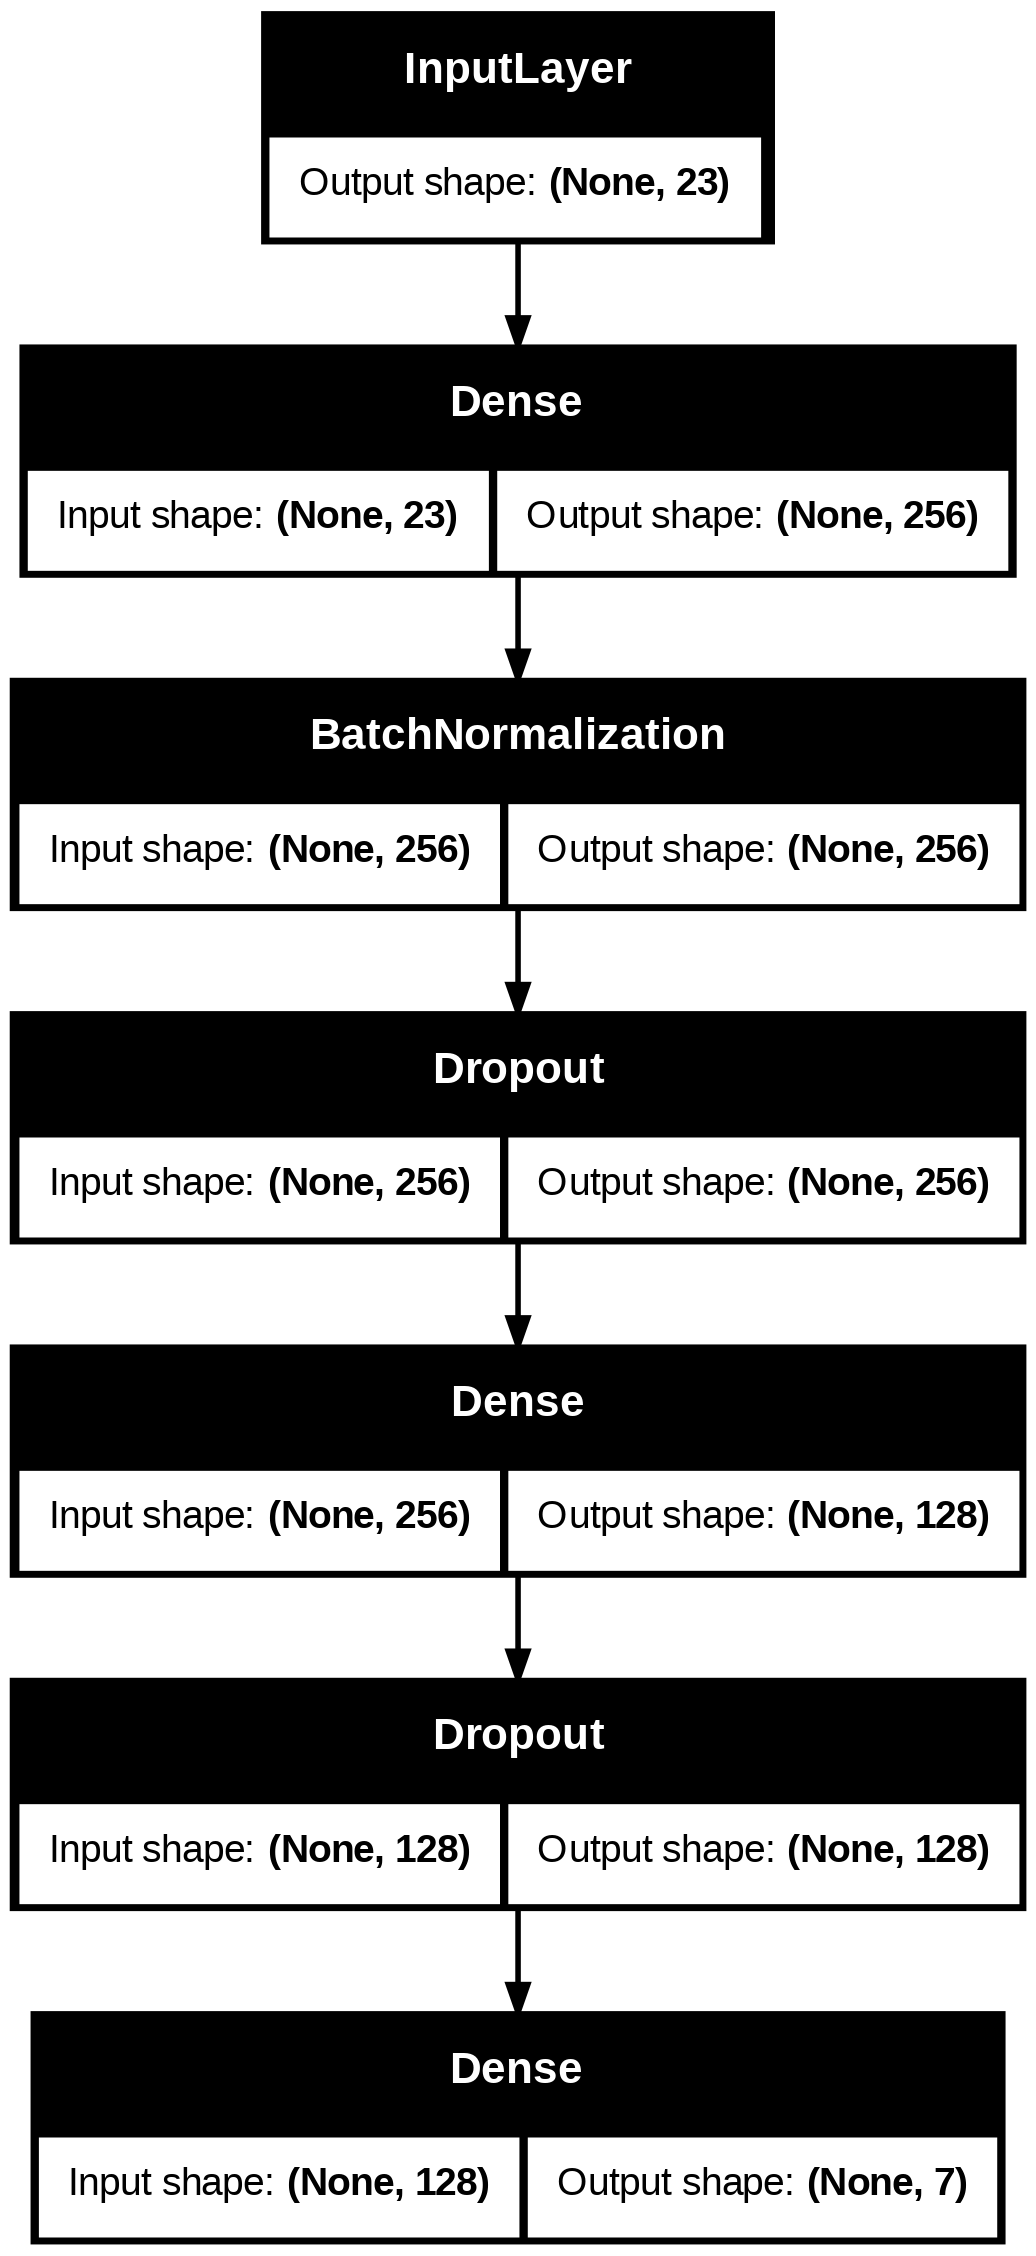

In [84]:
tabular_model = Model(inputs=[tabular_input], outputs=tabular_output)
tabular_model.summary()
plot_model(tabular_model, show_shapes=True)

In [85]:
#Extración de caracteristicas
feature_extractor = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
feature_extractor.trainable = False
feature_extractor.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [92]:
#Capa de input y preprocesamiento
#image_input = Input(shape=(224, 224, 3))
image_input = Input(shape=(image_size[0], image_size[1], 3), name="image_input")
preprocessed_input = Lambda(preprocess_input)(image_input)

#Capa de extraccción de caracteristicas de un modelo
image_features = feature_extractor(preprocessed_input, training=False)

#Capa de conversión a Flatten
flattened_features = GlobalAveragePooling2D()(image_features)
dropped_flattened = Dropout(0.25)(flattened_features)
intermediate_layer = Dense(256, activation="relu")(dropped_flattened)
intermediate_layer = Dropout(0.3)(intermediate_layer)

intermediate_layer = Dense(128, activation="relu")(intermediate_layer)
intermediate_layer = Dropout(0.3, name="image_features")(intermediate_layer)

#Clasificacion
image_output = Dense(len(class_names), activation="softmax", name="image_output")(intermediate_layer)

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_features (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_output (Dense)            │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,055 (92.11 MB)

 Trainable params: 558,343 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

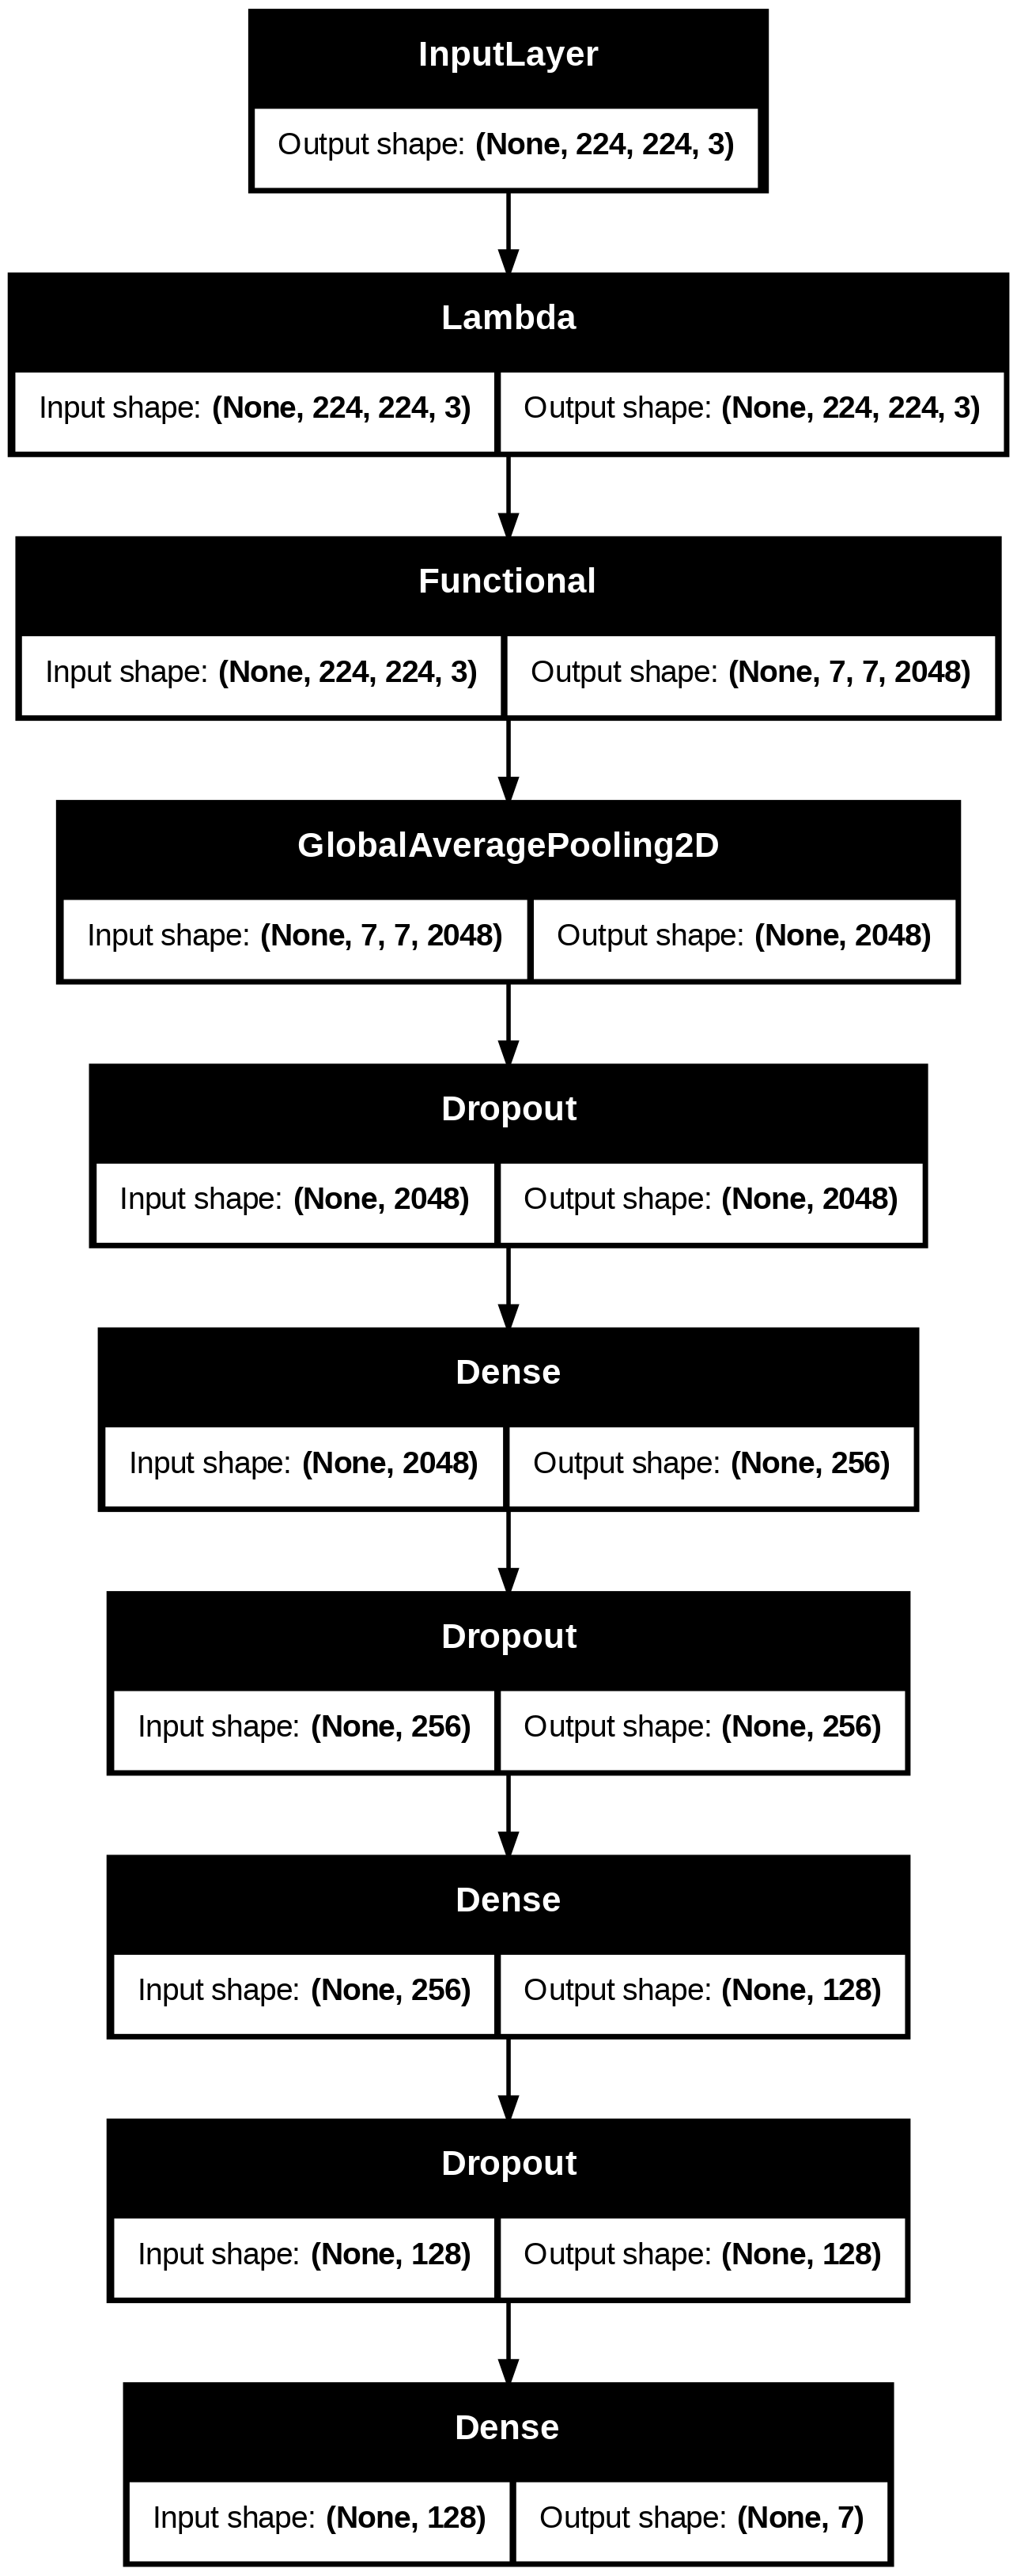

In [93]:
#Creación de modelo
image_model = Model(inputs=image_input, outputs=image_output)
image_model.summary()
plot_model(image_model, show_shapes=True)

In [94]:
#Early fusion

# Extración de la capa de caracteristicas de cada modelo
tabular_intermediate = Model(
  inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
image_intermediate = Model(
  inputs=image_model.input, outputs=image_model.get_layer('image_features').output)

tabular_features = tabular_intermediate(tabular_input)
image_features = image_intermediate(image_input)

# Fusion de los modelos, concatenandolos
merged = Concatenate()([tabular_features, image_features])

# Capa de clasificación
x = Dense(128, activation="relu")(merged)
x = Dense(64, activation="relu")(x)

output = tf.keras.layers.Dense(len(class_names), activation="softmax",)(x)

In [95]:
early_model =  tf.keras.Model(inputs=[tabular_input, image_input], outputs=output)
early_model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_16       │ (None, 128)       │     40,064 │ tabular_input[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_17       │ (None, 128)       │ 24,145,152 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256)       │          0 │ functional_16[0]… │
│ (Concatenate)       │                   │            │ functional_17[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │     32,896 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      8,256 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 7)         │        455 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,226,823 (92.42 MB)

 Trainable params: 638,599 (2.44 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

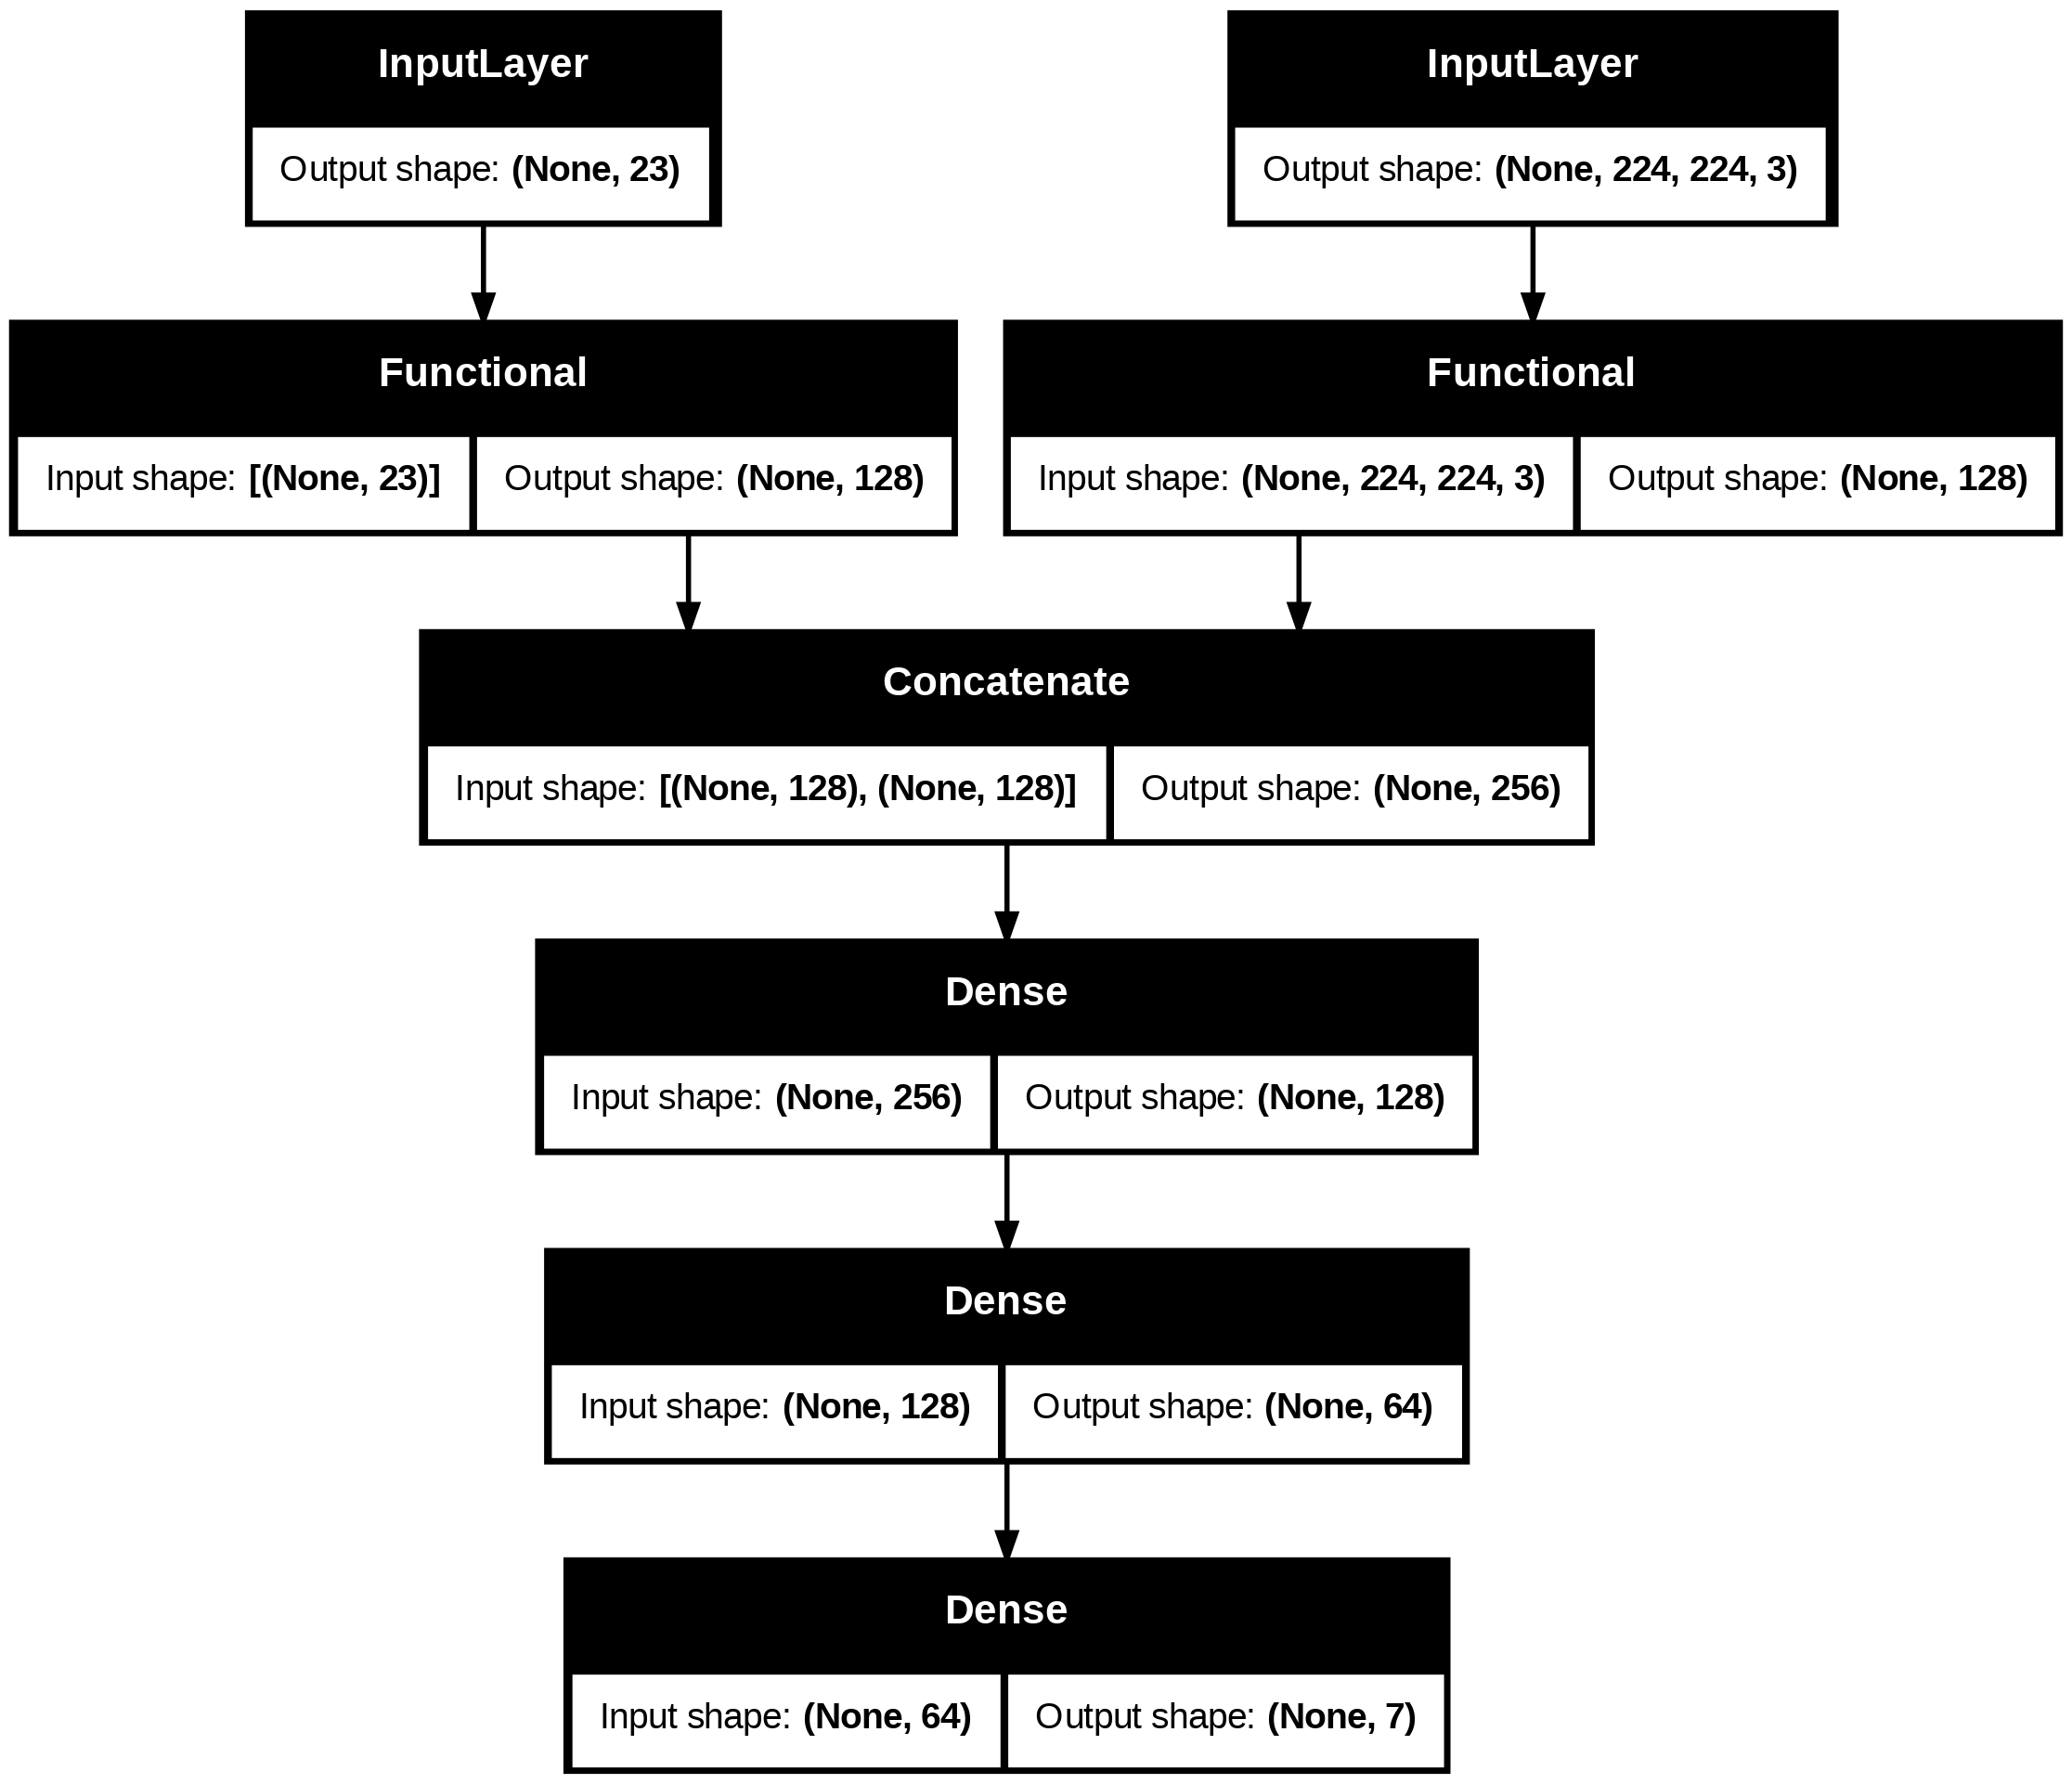

In [96]:
plot_model(early_model, show_shapes=True)

In [97]:
early_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_frozen),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = early_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6877 - loss: 0.8697 - val_accuracy: 0.6923 - val_loss: 0.8525
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 968ms/step - accuracy: 0.7338 - loss: 0.6812 - val_accuracy: 0.7323 - val_loss: 0.7846
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 822ms/step - accuracy: 0.7575 - loss: 0.6204 - val_accuracy: 0.7393 - val_loss: 0.7836
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 891ms/step - accuracy: 0.7713 - loss: 0.5869 - val_accuracy: 0.7003 - val_loss: 0.7459
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 844ms/step - accuracy: 0.7836 - loss: 0.5573 - val_accuracy: 0.7832 - val_loss: 0.6082
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 847ms/step - accuracy: 0.7876 - loss: 0.5401 - val_accuracy: 0.7932 - val_loss: 0.5525
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 847ms/step - accuracy: 0.8010 - loss: 0.5149 - val_accuracy: 0.8002 - val_loss: 0.5469
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 922ms/step - accuracy: 0.8092 - loss: 0.5008 - val_accura